In [3]:
import yfinance as yf
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
stocks = ["AMZN", "MSFT", "GOOG"]  # List of stock tickers
#start = dt.datetime.today() - dt.timedelta(360) # 30 days ago
#end = dt.datetime.today()

ohlcv_data = {}  # Dictionary to hold OHLCV data. Key-Value pair: Ticker-DataFrame

# get closing prices for each stock
for ticker in stocks:
    temp = yf.download(ticker, period="1y", interval="1d")
    temp.dropna(how="any", inplace=True) # type: ignore
    ohlcv_data[ticker] = temp



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


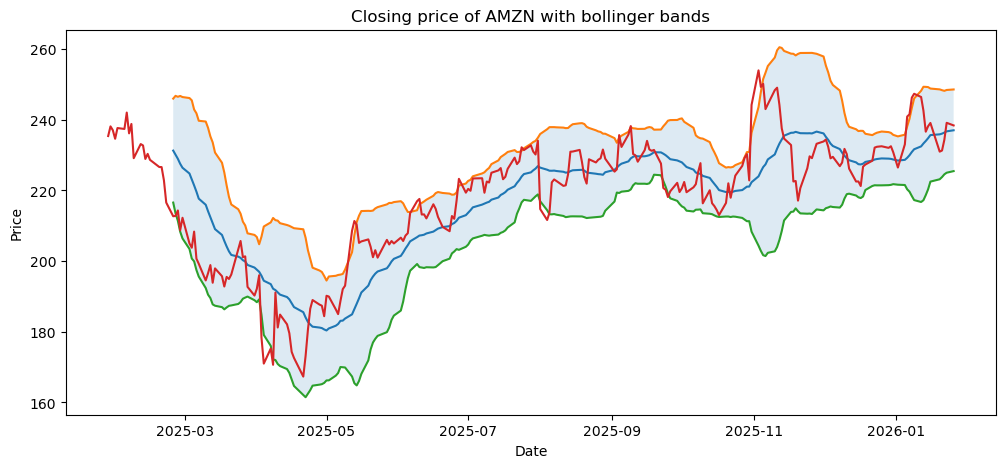

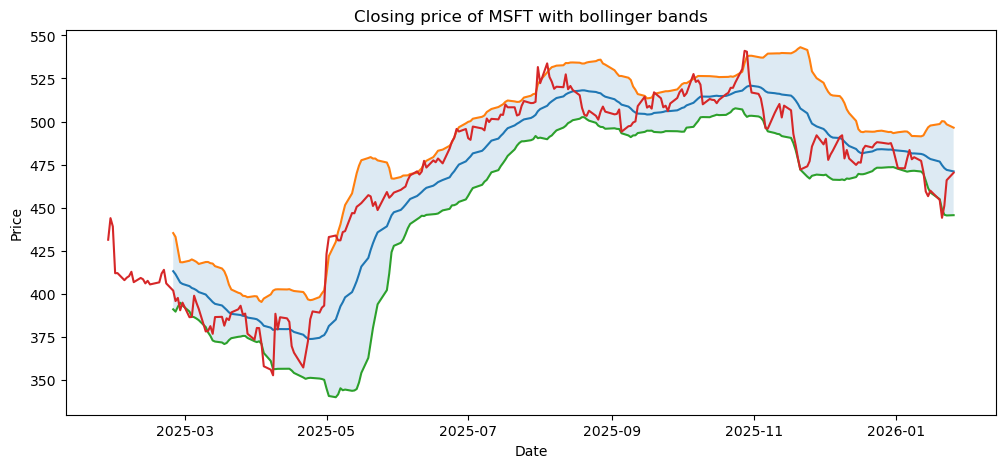

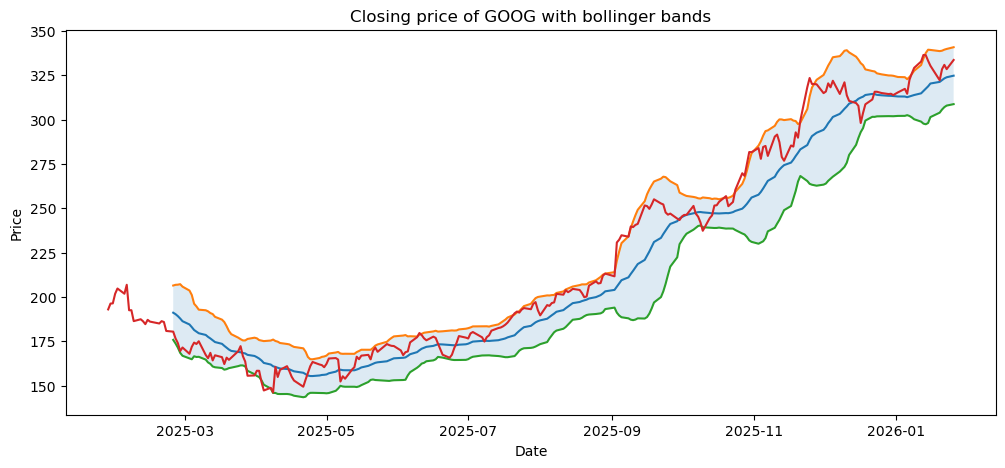

In [5]:
# bollinger bands
# upper and lower bands at distance of 2 stdev from closing price

def boll_band(DF, n = 20, k = 2):
    df = DF.copy()

    close = df["Close"]  # must be a Series

    mb = close.rolling(n).mean() # middle band
    sd = close.rolling(n).std(ddof=0) # stdev

    df["MB"] = mb # middle band
    df["UB"] = mb + k * sd # upper band
    df["LB"] = mb - k * sd # lower band
    df["BB_Width"] = df["UB"] - df["LB"] # width

    return df[["MB", "UB", "LB", "BB_Width"]]

for ticker in ohlcv_data:
    ohlcv_data[ticker][["MB", "UB", "LB", "BB_Width"]] = boll_band(ohlcv_data[ticker])

for ticker, df in ohlcv_data.items():
    df = ohlcv_data[ticker]

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # price + bollinger bands
    ax1.plot(df.index, df["MB"])
    ax1.plot(df.index, df["UB"])
    ax1.plot(df.index, df["LB"])
    ax1.plot(df.index, df["Close"], label="Closing Price")
    ax1.set_title(f"Closing price of {ticker} with bollinger bands")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Date")

    # shade between bands
    ax1.fill_between(df.index, df["LB"], df["UB"], alpha=0.15)

    plt.show()
